In [1]:
from PIL import Image

def img_sect(img, sections,orientation="h"):
    """
    Divide una imagen en secciones iguales.
    
    :param ruta_imagen: String con la ruta del archivo o un objeto Image de PIL.
    :param orientacion: 'vertical' (corte de arriba a abajo) o 'horizontal' (corte de izquierda a derecha).
    :param num_secciones: Entero con la cantidad de partes deseadas.
    :return: Lista de objetos Image.
    """
    ancho, alto = img.size
    secciones = []

    if orientation.lower() == 'v':
        # Corta la imagen en "rebanadas" verticales (izquierda a derecha)
        ancho_seccion = ancho // sections
        for i in range(sections):
            # Coordenadas: (izquierda, superior, derecha, inferior)
            izquierda = i * ancho_seccion
            derecha = (i + 1) * ancho_seccion if i < sections - 1 else ancho
            corte = img.crop((izquierda, 0, derecha, alto))
            secciones.append(corte)

    elif orientation.lower() == 'h':
        # Corta la imagen en "rebanadas" horizontales (arriba hacia abajo)
        alto_seccion = alto // sections
        for i in range(sections):
            superior = i * alto_seccion
            inferior = (i + 1) * alto_seccion if i < sections - 1 else alto
            corte = img.crop((0, superior, ancho, inferior))
            secciones.append(corte)
    
    else:
        raise ValueError("La orientación debe ser 'vertical' o 'horizontal'")

    return secciones

In [138]:
img = Image.open("mosaic4.png")
w,h = img.size
img = img.resize ((w//6,h//6))

cuts = 16
sections = img_sect(img,cuts,orientation='v')

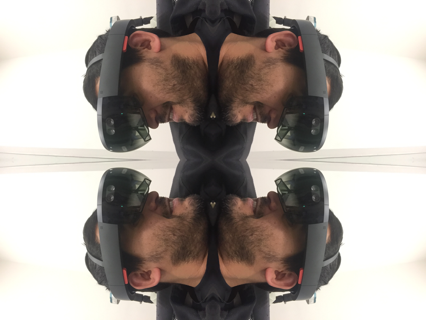

In [140]:
img

In [142]:
vc = Image.new('RGB', (img.size))
cutidx = list(range(cuts))
for i in range(len(cutidx)//2):
    idxa, idxb = cutidx[i], cutidx[-(i+1)]
    imga = sections[idxa]
    imgb = sections[idxb]
    #print(idxa,idxb)
    coordsa,coordsb = sections[0].width*(i*2), sections[0].width*(2*i- 1) + sections[0].width*(2)
    #print(coordsa,coordsb) 
    vc.paste(imga, (coordsa,0) )
    vc.paste(imgb, (coordsb,0) )
    #print(idxb)
    #print(coordsb,0)
    
    #print(idxa)
    #print(coordsa,0)  

In [144]:
sections2 = img_sect(vc,cuts,orientation='h')

In [146]:
vc2 = Image.new('RGB', (vc.size))
cutidx = list(range(cuts))
for i in range(len(cutidx)//2):
    idxa, idxb = cutidx[i], cutidx[-(i+1)]
    imga = sections2[idxa]
    imgb = sections2[idxb]
    #print(idxa,idxb)
    coordsa,coordsb = sections2[0].height*(i*2), sections2[0].height*(2*i- 1) + sections2[0].height*(2)
    #print(coordsa,coordsb) 
    vc2.paste(imga, (0,coordsa) )
    vc2.paste(imgb, (0,coordsb) )
    #print(idxb)
    #print(coordsb,0)
    
    #print(idxa)
    #print(coordsa,0)  

In [148]:
vc2 = vc2.rotate(-90)

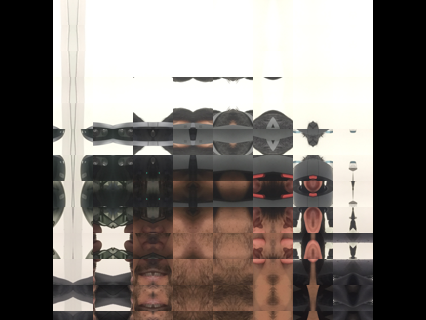

In [150]:
vc2

In [54]:
input_path = "/Users/xixarron/Downloads/IMG_0548.JPG"
original= Image.open(input_path)
original = original.resize ((w//6,h//6))
original = original.rotate(-90)

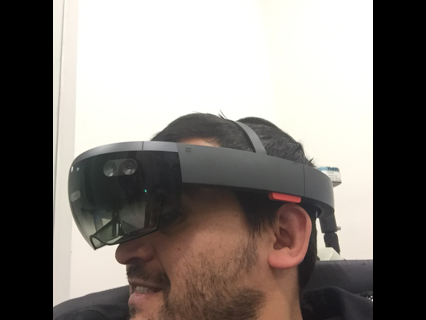

In [56]:
original